In [1]:

import kagglehub
alkanerturan_vehicledetection_path = kagglehub.dataset_download('alkanerturan/vehicledetection')

print('Data source import complete.')


100%|██████████| 62.8M/62.8M [00:04<00:00, 15.8MB/s]

Extracting files...


Data source import complete.


In [2]:

import numpy as np
import pandas as pd



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



# Load a pre-trained Faster R-CNN & run it on a sample image.

In [3]:
import torch
import torchvision
from torchvision import transforms
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import cv2

In [4]:
import yaml

In [6]:
import os

input_path = "/kaggle/input"
for root, dirs, files in os.walk(input_path):
    print(root)
    for file in files:
        print("  -", file)


/kaggle/input


In [7]:
print(alkanerturan_vehicledetection_path)


/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3


In [8]:
os.listdir(alkanerturan_vehicledetection_path)


['VehiclesDetectionDataset', 'TestVideo']

In [9]:
data_yaml_path = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/dataset.yaml'

with open(data_yaml_path, 'r') as file:
    data_config = yaml.safe_load(file)

class_names = data_config['names']
print("Custom class names:", class_names)

Custom class names: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']


In [10]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 187MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [11]:
# Define a transform to convert PIL image to tensor
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [12]:
print(transform)

Compose(
    ToTensor()
)


In [14]:
# Define the sample image path from your vehicle detection dataset
# Adjust the directory if necessary
train_images_dir = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/train/images'

sample_image_name = os.listdir(train_images_dir)[15]
sample_image_path = os.path.join(train_images_dir, sample_image_name)
print("Sample image path:", sample_image_path)

Sample image path: /root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/train/images/04c1d6c2570a7c42_jpg.rf.332b41cd0fd290fd0506dac060c1b7d6.jpg


In [15]:
sample_image_path = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/train/images/02d437a356a7c16e_jpg.rf.vHLFLzl61byax6BaLMCP.jpg'


In [16]:
# Load and transform the sample image
img_pil = Image.open(sample_image_path).convert("RGB")
img_tensor = transform(img_pil)
print(img_tensor)

tensor([[[0.0353, 0.0588, 0.0824,  ..., 0.0745, 0.0706, 0.0706],
         [0.0627, 0.0784, 0.0941,  ..., 0.0784, 0.0745, 0.0745],
         [0.0510, 0.0667, 0.0863,  ..., 0.0784, 0.0745, 0.0745],
         ...,
         [0.0627, 0.0667, 0.0667,  ..., 0.1922, 0.1961, 0.2039],
         [0.0627, 0.0667, 0.0667,  ..., 0.1961, 0.2000, 0.2039],
         [0.0627, 0.0667, 0.0667,  ..., 0.2000, 0.2039, 0.2078]],

        [[0.0471, 0.0706, 0.0941,  ..., 0.0824, 0.0706, 0.0667],
         [0.0745, 0.0902, 0.1059,  ..., 0.0824, 0.0745, 0.0706],
         [0.0627, 0.0784, 0.0980,  ..., 0.0824, 0.0784, 0.0745],
         ...,
         [0.0588, 0.0627, 0.0627,  ..., 0.1922, 0.1961, 0.2039],
         [0.0588, 0.0627, 0.0627,  ..., 0.1961, 0.2000, 0.2039],
         [0.0588, 0.0627, 0.0627,  ..., 0.2000, 0.2039, 0.2078]],

        [[0.0039, 0.0275, 0.0667,  ..., 0.0000, 0.0627, 0.0980],
         [0.0314, 0.0471, 0.0784,  ..., 0.0118, 0.0667, 0.0941],
         [0.0196, 0.0353, 0.0706,  ..., 0.0275, 0.0588, 0.

In [17]:
# Perform inference
with torch.no_grad():
    predictions = model([img_tensor])[0]

print("Predictions:", predictions)

Predictions: {'boxes': tensor([[193.3908, 220.8244, 382.2046, 399.2934],
        [263.8519, 201.9873, 329.8152, 237.1345],
        [208.8984, 191.8224, 230.5652, 218.4047],
        [124.7621, 199.4280, 136.0310, 210.6824],
        [157.9561, 194.2521, 185.0605, 236.7243],
        [225.3089, 187.4047, 237.6657, 196.3712],
        [158.6606, 190.8103, 176.7484, 201.3130],
        [158.2646, 191.4323, 178.0361, 210.4300],
        [265.0995, 200.1209, 349.1691, 256.2941],
        [ 90.3090, 218.4372, 103.7916, 260.9426],
        [ 89.4145, 218.4979, 103.2889, 256.1284],
        [267.0368, 201.7063, 317.1509, 225.0248],
        [ 90.4651, 218.8004, 104.5701, 261.8652],
        [235.7623, 198.4887, 297.0212, 224.5776],
        [157.8826, 192.0837, 184.9579, 236.6080],
        [208.2033, 190.9679, 230.6775, 217.8745],
        [ 52.7622, 193.0846, 319.7964, 400.7741]]), 'labels': tensor([ 3,  3,  3,  3,  3,  3,  3,  3,  3, 62,  3,  3, 15,  3,  8,  8,  3]), 'scores': tensor([0.9969, 0.9815, 0.9

In [18]:
def draw_boxes_fasterrcnn(image, predictions, class_names, threshold=0.8):
    """
    Annotate the image with bounding boxes, class names, and scores.
    Args:
        image (PIL.Image): The original image.
        predictions (dict): Predictions from Faster R-CNN containing 'boxes', 'labels', and 'scores'.
        class_names (list): List of custom class names. Assumes model outputs are 1-indexed relative to these classes.
        threshold (float): Confidence threshold.
    Returns:
        Annotated image in BGR format.
    """
    # Convert the PIL image to a numpy array (RGB) and then convert to BGR for OpenCV
    image_np = np.array(image)
    image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    boxes = predictions['boxes'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()

    # Loop through detections and annotate those above the threshold
    for i, score in enumerate(scores):
        if score >= threshold:
            box = boxes[i].astype(int)
            # Adjust label: if your model was fine-tuned on your custom dataset,
            # then it should output labels in the range [1, nc]. We subtract 1 to index into class_names.
            label_idx = labels[i] - 1
            class_name = class_names[label_idx] if 0 <= label_idx < len(class_names) else str(labels[i])
            cv2.rectangle(image_bgr, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
            cv2.putText(image_bgr, f"{class_name}: {score:.2f}", (box[0], box[1] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return image_bgr

In [19]:
# Annotate the sample image using our draw_boxes_fasterrcnn function
annotated_image = draw_boxes_fasterrcnn(img_pil, predictions, class_names, threshold=0.8)

# Save the annotated image
output_image_path = "fasterrcnn_annotated_sample.jpg"
cv2.imwrite(output_image_path, annotated_image)
print("Annotated image saved to", output_image_path)

Annotated image saved to fasterrcnn_annotated_sample.jpg


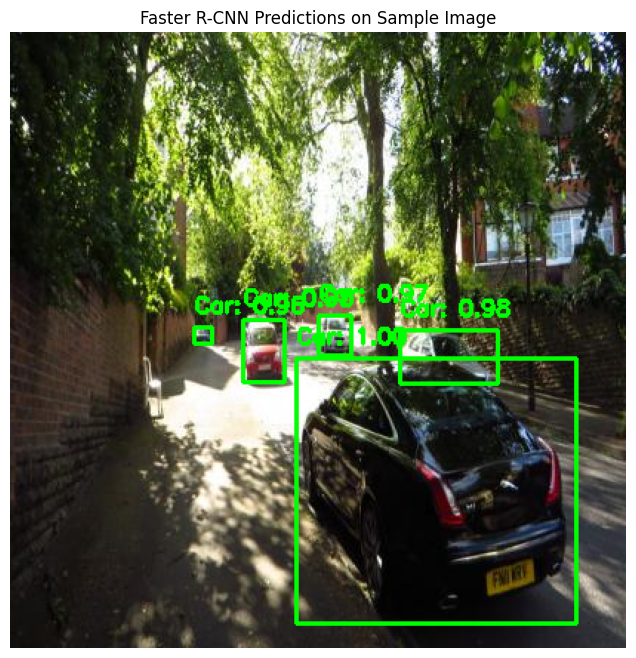

In [20]:
# Display the annotated image using Matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title("Faster R-CNN Predictions on Sample Image")
plt.axis("off")
plt.show()

# finetuning faster Rcnn

<!-- Finetuning Faster RCNN -->

In [21]:
from torch.utils.data import Dataset, DataLoader

In [22]:
class VehicleDataset(Dataset):
    """
    Custom Dataset for Vehicle Detection.
    Assumes:
      - Images in image_dir.
      - Corresponding labels in label_dir with same filename (but extension .txt).
      - Each label file contains lines: "class x_center y_center width height" (normalized).
    """
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.image_files = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Get image path and corresponding label file path
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, os.path.splitext(img_name)[0] + '.txt')

        # Load image
        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        # Initialize target dictionary as expected by Faster R-CNN
        target = {}
        boxes = []
        labels = []

        # Read label file if exists and is non-empty
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.read().strip().splitlines()
            for line in lines:
                # Each line: class x_center y_center width height
                # If label file is empty, then lines will be []
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls, cx, cy, w, h = map(float, parts)
                # Convert normalized center coordinates to pixel coordinates:
                xmin = (cx - w/2) * width
                ymin = (cy - h/2) * height
                xmax = (cx + w/2) * width
                ymax = (cy + h/2) * height
                boxes.append([xmin, ymin, xmax, ymax])
                # For training Faster R-CNN, labels should be integers.
                # Here we assume that the YOLO class ids are 0-indexed.
                labels.append(int(cls) + 1)  # We add 1 to reserve 0 for background.

        # Convert to tensors
        target["boxes"] = torch.as_tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.as_tensor(labels, dtype=torch.int64)
        # Optionally, you can add image_id, area, and iscrowd if needed.
        target["image_id"] = torch.tensor([idx])
        if boxes:
            areas = [(box[2]-box[0])*(box[3]-box[1]) for box in boxes]
        else:
            areas = []
        target["area"] = torch.as_tensor(areas, dtype=torch.float32)
        target["iscrowd"] = torch.zeros((len(boxes),), dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        return image, target


In [23]:

# Collate function for DataLoader
def collate_fn(batch):
    return tuple(zip(*batch))

In [25]:

train_images_dir = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/train/images'
train_labels_dir = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/train/labels'
val_images_dir = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/valid/images'
val_labels_dir = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/valid/labels'


# Define a basic transform (we resize images to 640x640)
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((640, 640))
])
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((640, 640))
])

train_dataset = VehicleDataset(train_images_dir, train_labels_dir, transform=transform_train)
val_dataset = VehicleDataset(val_images_dir, val_labels_dir, transform=transform_val)

# Hyperparameters: you can experiment with different batch sizes.
batch_size = 4  # initial batch size (try 2, 4, 8 as needed)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn)

print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(val_dataset))


Number of training images: 878
Number of validation images: 250


In [27]:
import torch

# Set the device (use GPU if available, otherwise use CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = 5 + 1  # 5 classes + 1 for background

# Load a pretrained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Replace the classifier head with a new one (FastRCNNPredictor)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# Move model to the appropriate device
model.to(device)

Using device: cuda


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [28]:
import os
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import yaml
import cv2
import time
import matplotlib.pyplot as plt

In [29]:

learning_rate = 0.005  # initial learning rate; try 0.001, 0.005, 0.01 etc.

# Use SGD with momentum (common for detection)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=0.9, weight_decay=0.0005)
# Learning rate scheduler: reduce LR by 10% every 3 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.9)

num_epochs = 10  # as specified

print("Starting training for {} epochs with learning rate {} and batch size {}".format(num_epochs, learning_rate, batch_size))
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()
    for images, targets in train_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        loss_value = losses.item()
        epoch_loss += loss_value

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    lr_scheduler.step()
    epoch_time = time.time() - start_time
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_time:.2f}s")

Starting training for 10 epochs with learning rate 0.005 and batch size 4
Epoch 1/10, Loss: 0.4135, Time: 162.66s
Epoch 2/10, Loss: 0.3599, Time: 163.00s
Epoch 3/10, Loss: 0.3216, Time: 163.01s
Epoch 4/10, Loss: 0.2777, Time: 162.98s
Epoch 5/10, Loss: 0.2319, Time: 162.90s
Epoch 6/10, Loss: 0.2010, Time: 162.94s
Epoch 7/10, Loss: 0.1664, Time: 162.78s
Epoch 8/10, Loss: 0.1472, Time: 162.78s
Epoch 9/10, Loss: 0.1345, Time: 162.66s
Epoch 10/10, Loss: 0.1213, Time: 162.65s


In [30]:

# Save the model checkpoint
checkpoint_path = "fasterrcnn_vehicle_checkpoint.pth"
torch.save(model.state_dict(), checkpoint_path)
print("Model checkpoint saved to", checkpoint_path)

Model checkpoint saved to fasterrcnn_vehicle_checkpoint.pth


In [31]:
loss_dict = model(images, targets)
print(loss_dict)  # Check what the model returns

{'loss_classifier': tensor(0.0389, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1037, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0050, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0095, device='cuda:0', grad_fn=<DivBackward0>)}


Analyse the impact of different learning rates and batch sizes on performance.

In [32]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml

In [33]:

# Load a pretrained Faster R-CNN model and update its head
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
# Load the fine-tuned checkpoint
checkpoint_path = "fasterrcnn_vehicle_checkpoint.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [34]:

# Define transformation: convert image to tensor and optionally resize (if needed)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Define a function to draw bounding boxes with class names and confidence scores
def draw_boxes_fasterrcnn(image, predictions, class_names, threshold=0.5):
    """
    Draw bounding boxes, class names, and confidence scores on the input image.
    Args:
        image (PIL.Image): Original input image.
        predictions (dict): Output of the model containing 'boxes', 'labels', 'scores'.
        class_names (list): List of custom class names (assumes model outputs are 1-indexed).
        threshold (float): Confidence threshold.
    Returns:
        Annotated image (in BGR format) as a NumPy array.
    """
    # Convert PIL image to numpy array (RGB) then to BGR for OpenCV
    image_np = np.array(image)
    image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    boxes = predictions['boxes'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()

    for i, score in enumerate(scores):
        if score >= threshold:
            box = boxes[i].astype(int)
            # Assuming model outputs labels in [1, num_classes-1] and we map (label - 1) to custom names
            label_idx = labels[i] - 1
            class_name = class_names[label_idx] if 0 <= label_idx < len(class_names) else str(labels[i])
            cv2.rectangle(image_bgr, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
            cv2.putText(image_bgr, f"{class_name}: {score:.2f}", (box[0], box[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return image_bgr

# Define a function that takes an image path, runs inference with Faster R-CNN,
# and returns the annotated image.
def annotate_image(image_path, threshold=0.5):
    """
    Given an image path, this function loads the image, runs Faster R-CNN inference,
    draws bounding boxes with class names and confidence scores, and returns the annotated image.
    """
    # Load image
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).to(device)

    # Run inference
    with torch.no_grad():
        predictions = model([img_tensor])[0]

    # Draw boxes on the image
    annotated = draw_boxes_fasterrcnn(image, predictions, class_names, threshold=threshold)
    return annotated

Annotated image saved to annotated_00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg


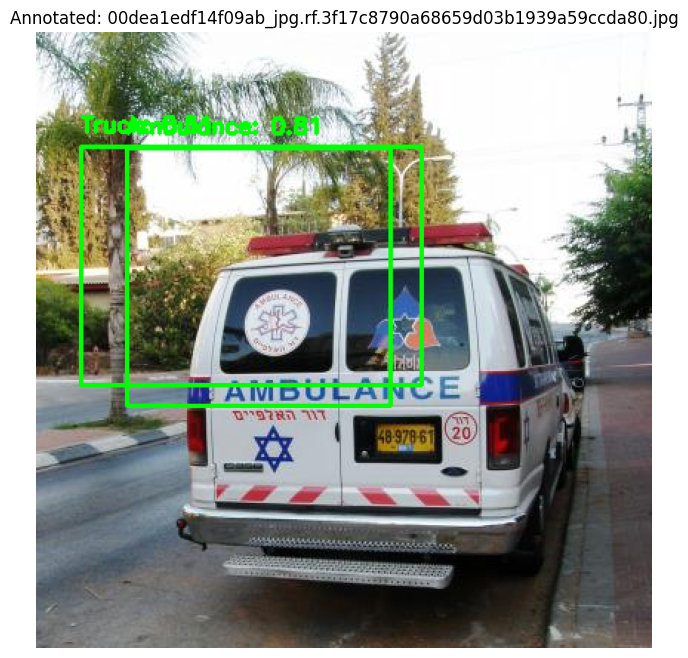

Annotated image saved to annotated_00dea1edf14f09ab_jpg.rf.KJ730oDTFPdXdJxvSLnX.jpg


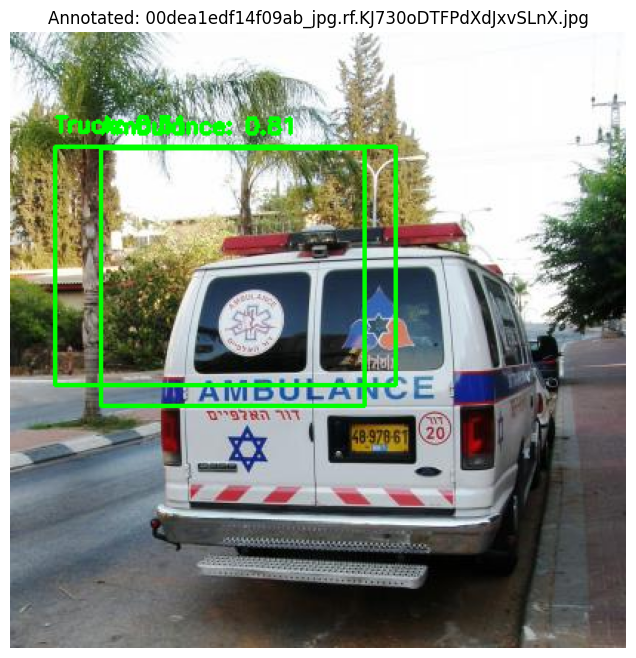

Annotated image saved to annotated_00e481ea1a520175_jpg.rf.6e6a8b3b45c9a11d106958f88ff714ea.jpg


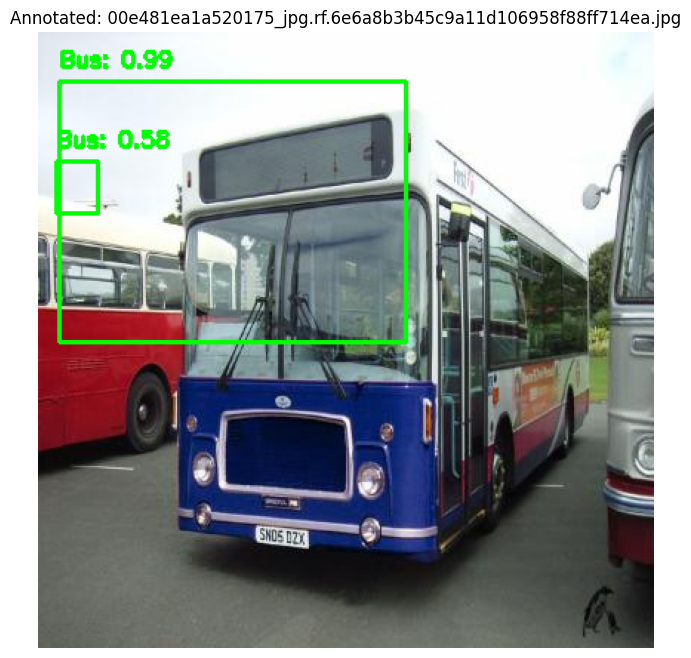

Annotated image saved to annotated_00e481ea1a520175_jpg.rf.MV6sZ8QCFwFeMYaI2tHm.jpg


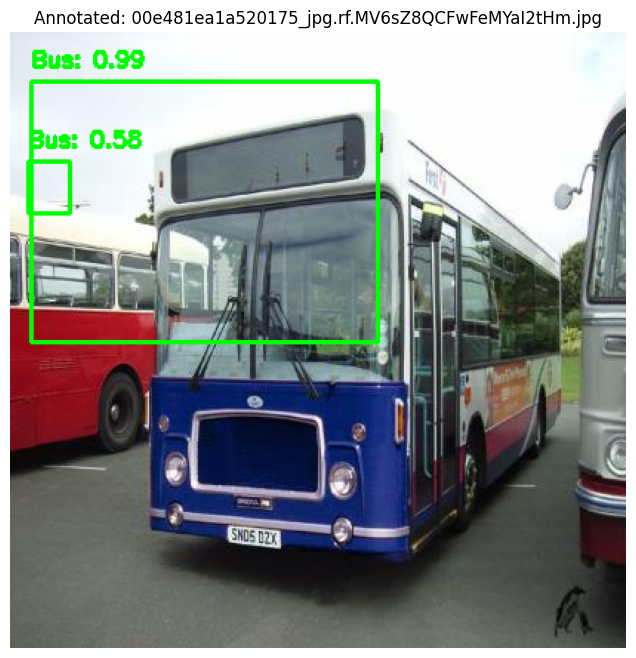

Annotated image saved to annotated_08c8b73e0c2e296e_jpg.rf.7IkYAamjZhnwsoXSrwKt.jpg


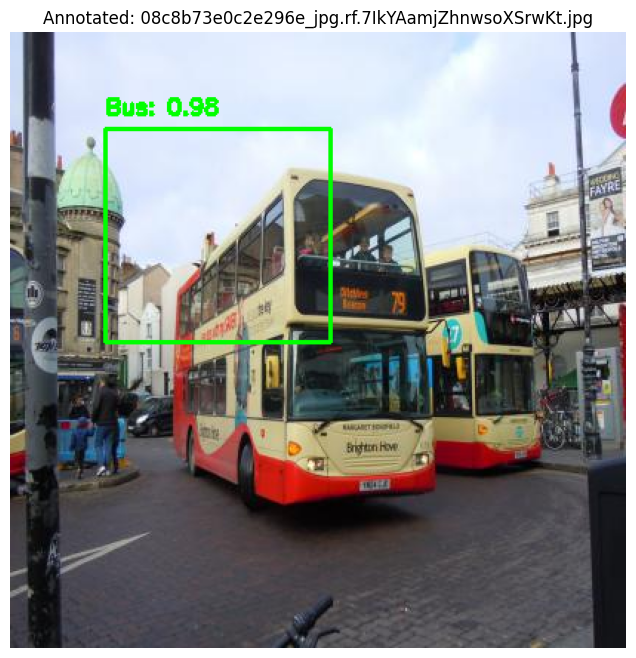

In [35]:
# --- Testing on a few images from the test dataset ---
test_images_dir = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/test/images'

test_image_files = sorted(os.listdir(test_images_dir))

# Let's annotate and display the first 5 test images
for img_file in test_image_files[:5]:
    img_path = os.path.join(test_images_dir, img_file)
    annotated = annotate_image(img_path, threshold=0.5)

    # Save the annotated image
    output_path = f"annotated_{img_file}"
    cv2.imwrite(output_path, annotated)
    print("Annotated image saved to", output_path)

    # Display the annotated image
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Annotated: {img_file}")
    plt.axis("off")
    plt.show()

# Analyse metrics related to Faster RCNN

In [38]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Initialize the metric
metric = MeanAveragePrecision()

model.eval()
val_loss = 0
with torch.no_grad():
    for images, targets in val_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Model inference (no loss calculation here)
        prediction = model(images)

        # Update the metric with the predictions and targets (ground truth)
        metric.update(prediction, targets)

# Compute and print mAP (mean Average Precision)
mean_ap = metric.compute()
print(f"mAP: {mean_ap}")

mAP: {'map': tensor(0.1571), 'map_50': tensor(0.3615), 'map_75': tensor(0.1232), 'map_small': tensor(0.), 'map_medium': tensor(0.0016), 'map_large': tensor(0.1981), 'mar_1': tensor(0.2199), 'mar_10': tensor(0.2647), 'mar_100': tensor(0.2647), 'mar_small': tensor(0.), 'mar_medium': tensor(0.0075), 'mar_large': tensor(0.3285), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([1, 2, 3, 4, 5], dtype=torch.int32)}


In [37]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

# Trying learning rate for 0.01 for  3 epoch

In [39]:

learning_rate = 0.01  # initial learning rate; try 0.001, 0.005, 0.01 etc.

# Use SGD with momentum (common for detection)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=0.9, weight_decay=0.0005)
# Learning rate scheduler: reduce LR by 10% every 3 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.9)

num_epochs = 3  # as specified

print("Starting training for {} epochs with learning rate {} and batch size {}".format(num_epochs, learning_rate, batch_size))
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()
    for images, targets in train_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        loss_value = losses.item()
        epoch_loss += loss_value

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    lr_scheduler.step()
    epoch_time = time.time() - start_time
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_time:.2f}s")

Starting training for 3 epochs with learning rate 0.01 and batch size 4
Epoch 1/3, Loss: 0.2081, Time: 165.64s
Epoch 2/3, Loss: 0.2215, Time: 163.13s
Epoch 3/3, Loss: 0.1626, Time: 163.14s


In [40]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision


metric = MeanAveragePrecision()

model.eval()
val_loss = 0
with torch.no_grad():
    for images, targets in val_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        prediction = model(images)
        metric.update(prediction, targets)

mean_ap = metric.compute()
print(f"mAP: {mean_ap}")

mAP: {'map': tensor(0.1391), 'map_50': tensor(0.3091), 'map_75': tensor(0.0904), 'map_small': tensor(0.), 'map_medium': tensor(0.0034), 'map_large': tensor(0.1714), 'mar_1': tensor(0.1850), 'mar_10': tensor(0.2453), 'mar_100': tensor(0.2454), 'mar_small': tensor(0.), 'mar_medium': tensor(0.0030), 'mar_large': tensor(0.3027), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([1, 2, 3, 4, 5], dtype=torch.int32)}


Annotated image saved to annotated_00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg


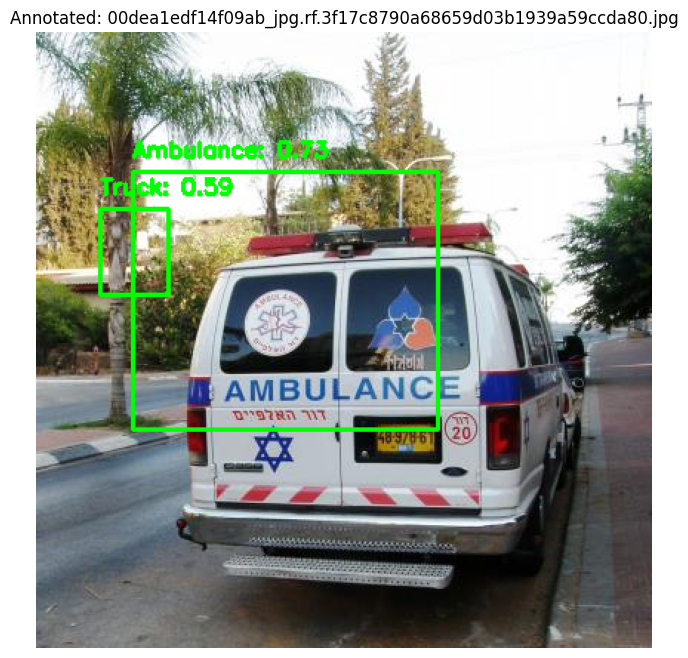

Annotated image saved to annotated_00dea1edf14f09ab_jpg.rf.KJ730oDTFPdXdJxvSLnX.jpg


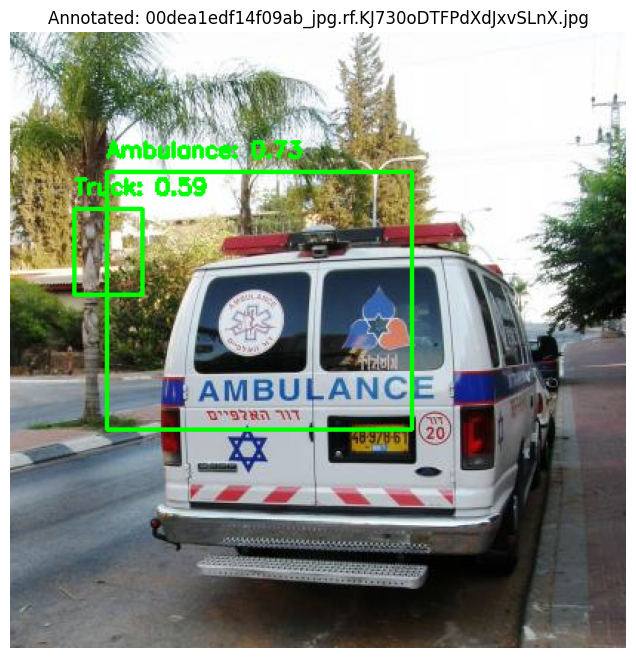

Annotated image saved to annotated_00e481ea1a520175_jpg.rf.6e6a8b3b45c9a11d106958f88ff714ea.jpg


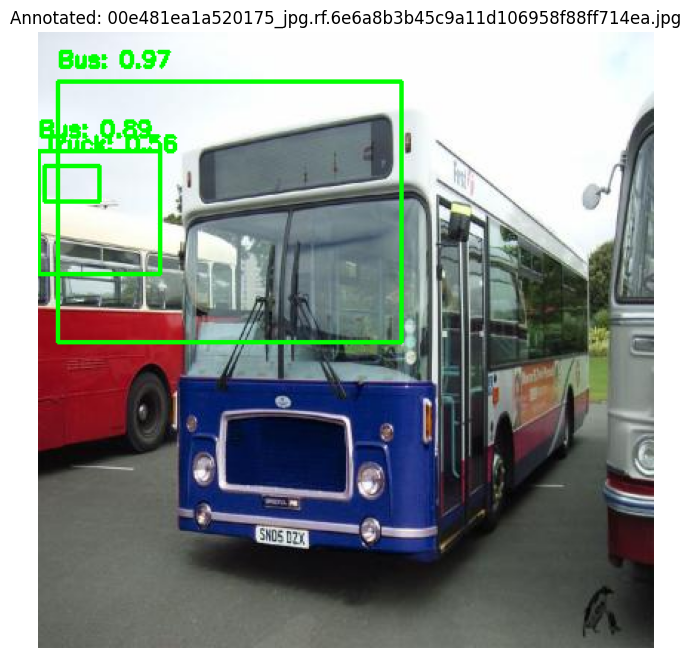

Annotated image saved to annotated_00e481ea1a520175_jpg.rf.MV6sZ8QCFwFeMYaI2tHm.jpg


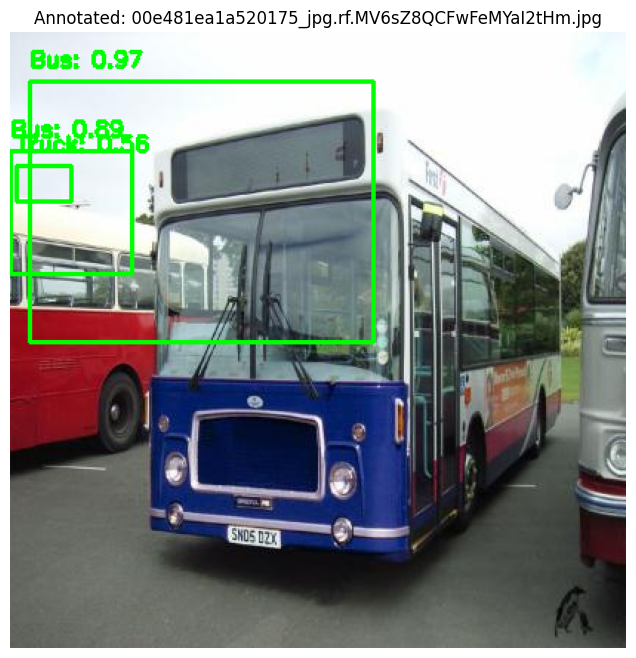

Annotated image saved to annotated_08c8b73e0c2e296e_jpg.rf.7IkYAamjZhnwsoXSrwKt.jpg


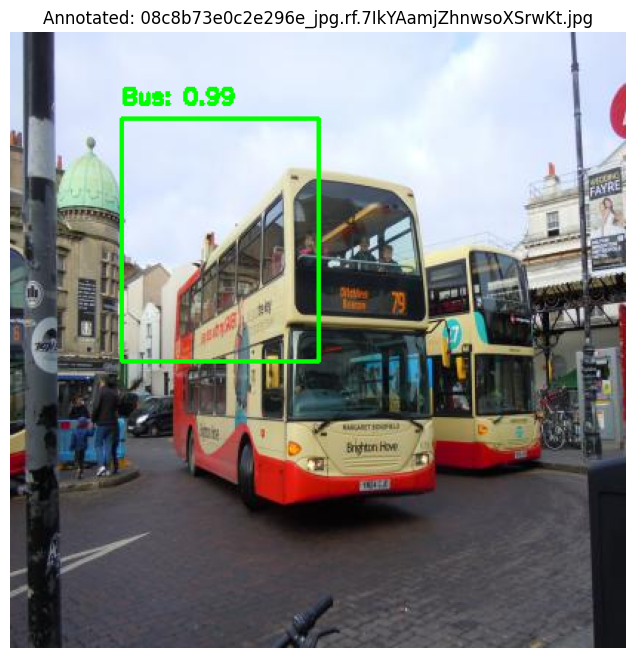

In [41]:
# --- Testing on a few images from the test dataset ---
test_images_dir = '/root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3/VehiclesDetectionDataset/test/images'

test_image_files = sorted(os.listdir(test_images_dir))

# Let's annotate and display the first 5 test images
for img_file in test_image_files[:5]:
    img_path = os.path.join(test_images_dir, img_file)
    annotated = annotate_image(img_path, threshold=0.5)

    # Save the annotated image
    output_path = f"annotated_{img_file}"
    cv2.imwrite(output_path, annotated)
    print("Annotated image saved to", output_path)

    # Display the annotated image
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Annotated: {img_file}")
    plt.axis("off")
    plt.show()